<a href="https://colab.research.google.com/github/RENSHUZHE/HKU-DQMC/blob/main/DQMC_Part_1_Prerequisite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Monte Carlo

The Monte Carlo method is a computational technique that uses random sampling to estimate numerical results and solve complex mathematical problems.

## Monte Carlo by directly sampling

The directly sampling method can be beautifully illustrated by a hypothetical game played by children in [Monte Carlo, Monaco](https://en.wikipedia.org/wiki/Monte_Carlo), the home of the famous casino that gave the technique its name. In this game, children randomly toss small pebbles into a square and calculate the ratio of stones that land inside an inscribed circle to estimate its relative area.

<>:32: SyntaxWarning: invalid escape sequence '\p'
<>:32: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1278/1370438315.py:32: SyntaxWarning: invalid escape sequence '\p'
  plt.title(f"Monte Carlo Pi Estimation\n$\pi \\approx$ {pi_estimate:.5f} (Samples: {num_samples:,})", fontsize=14)


Total Samples: 50,000
Points Inside Circle: 39,410
Estimated Pi: 3.152800
Actual Pi:    3.141593
Error:        0.011207


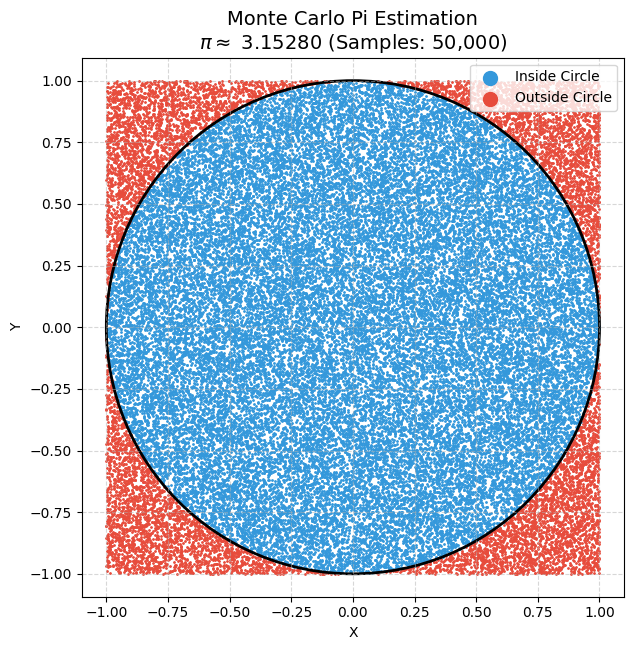

In [ ]:
def estimate_pi(num_samples=100000):
    # 1. Generate random (x, y) coordinates between -1 and 1
    # This represents throwing pebbles randomly into a 2x2 square
    points = np.random.uniform(-1, 1, size=(num_samples, 2))
    x, y = points[:, 0], points[:, 1]

    # 2. Check if the points fall inside the inscribed unit circle (x^2 + y^2 <= 1)
    distance_from_origin = x**2 + y**2
    inside_circle = distance_from_origin <= 1

    # 3. Calculate Pi estimate: 4 * (points inside / total points)
    num_inside = np.sum(inside_circle)
    pi_estimate = 4 * num_inside / num_samples

    print(f"Total Samples: {num_samples:,}")
    print(f"Points Inside Circle: {num_inside:,}")
    print(f"Estimated Pi: {pi_estimate:.6f}")
    print(f"Actual Pi:    {np.pi:.6f}")
    print(f"Error:        {abs(pi_estimate - np.pi):.6f}")

    # 4. Visualise the simulation
    plt.figure(figsize=(7, 7))

    # Plot points inside the circle in blue, outside in red
    plt.scatter(x[inside_circle], y[inside_circle], color='#3498db', s=1, label='Inside Circle')
    plt.scatter(x[~inside_circle], y[~inside_circle], color='#e74c3c', s=1, label='Outside Circle')

    # Draw the boundary circle line
    circle = plt.Circle((0, 0), 1, color='black', fill=False, linewidth=2)
    plt.gca().add_patch(circle)

    plt.title(f"Monte Carlo Pi Estimation\n$\pi \\approx$ {pi_estimate:.5f} (Samples: {num_samples:,})", fontsize=14)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.axis("equal")
    plt.xlim(-1.1, 1.1)
    plt.ylim(-1.1, 1.1)
    plt.legend(loc='upper right', markerscale=10)
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.show()

# Run the simulation
estimate_pi(num_samples=50000)

## Monte Carlo by Markov Chain

Now imagine the same game, but played by adults. For them, the playground is huge (perhaps 20 metres by 20 metres), and it is impossible to throw a pebble far enough to cover the entire square. Therefore, they change their strategy. Now, wherever they throw the pebble, they walk to that landing place, point in a random direction, and throw again. In this process, each throw is followed by the next and is no longer completely independent of the last throw. If they ever throw a pebble outside the square, they must fetch it, place it exactly on the spot of their previous throw, and continue from there.



### Monte Carlo Section

For a steady-state distribution $\pi(i)$, we have the detailed balance condition:

$$\pi(i) Q(i, j) \alpha(i, j)=\pi(j) Q(j, i) \alpha(j, i)$$

where $Q(i, j)$ represents the probability of attempting to transition from $i$ to $j$, and $\alpha(i, j)$ is the corresponding acceptance probability. We typically choose:

$$\alpha(i, j)=\min \left\{\frac{\pi(j) Q(j, i)}{\pi(i) Q(i, j)}, 1\right\}$$

In most cases, $Q(i, j)=Q(j,i)$. For example, in the Metropolis algorithm for the classical Ising model, the weight of each configuration is $\propto e^{-\beta E}$, and the acceptance probability is $\min \left\{e^{-\beta \Delta E}, 1\right\}$.

### Statistical Mechanics Section

For classical models, we have the partition function:

$$Z=\sum_{\sigma} e^{-\beta E_{\sigma}}$$

Physical observables:

$$\langle O\rangle=\frac{1}{Z} \sum_{C} O e^{-\beta E_{C}}$$

For quantum systems, the partition function is:

$$Z=\operatorname{Tr}\left\{e^{-\beta H}\right\}$$

Choosing a basis:

$$Z=\sum_{\{\phi\}}\left\langle\{\phi\}\left|e^{-\beta H}\right|\{\phi\}\right\rangle$$

Physical observables:

$$\langle O\rangle=\frac{\operatorname{Tr}\left\{O e^{-\beta H}\right\}}{Z}$$

### Trotter Decomposition

$$\begin{aligned}Z &=\operatorname{Tr}\left[e^{-\beta H}\right] \\&=\operatorname{Tr}\left[(e^{-\Delta \tau H_I} e^{-\Delta \tau H_0})^{L_{\tau}} \right] \\&=\operatorname{Tr}\left[e^{-\Delta \tau H_I} e^{-\Delta \tau H_0} \ldots e^{-\Delta \tau H_I} e^{-\Delta \tau H_0}\right] +\mathcal{O}\left[(\Delta \tau)^{2}\right]\end{aligned}$$

where $L_\tau =\frac{\beta}{\Delta \tau}$